In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pydicom
import os
#%matplotlib qt   # commented out so that the images can be seen in the notebook


In [2]:
import imageio
def get_vol_data(end_digits):  # define function to get data from dicom file
    vol_data = imageio.volread(r"C:\Users\slaar\Desktop\project\HippocampalMRISlices\01\MR.1.2.246.352.221.{}.dcm".format(str(end_digits)))  # read dicom file
    return vol_data  # return dicom data

def slices(number_of_slice, slice_type, end_digits):
    '''returns the information of the specified slice, to be plotted
    slice_type are defined as 'axial', 'coronal', and 'saggital' 
    number_of_slice defines the specific slice to be returned
    '''
    vol = get_vol_data(end_digits)
    if slice_type == 'axial':
        return vol[number_of_slice,:,:]
    elif slice_type == 'coronal':
        return vol[:,number_of_slice,:]
    elif slice_type == 'saggital':
        return vol[:,:,number_of_slice]
    else:
        raise ValueError("Please choose from 'axial', 'coronal', or 'saggital', and a slice number must be between 0 and 255")

axial_slice = slices(90, 'axial', 551459698506200377412175303061706085291)
saggital_slice = slices(90, 'saggital', 551459698506200377412175303061706085291)
coronal_slice = slices(90, 'coronal', 551459698506200377412175303061706085291)

Reading DICOM (examining files): 1/278 files (0.4110/278 files (39.6%215/278 files (77.3%249/278 files (89.6%253/278 files (91.0%263/278 files (94.6%271/278 files (97.5  DICOM file has no SamplesPerPixel (perhaps this is a report?)
Reading DICOM (examining files): 271/278 files (97.5%278/278 files (100.0%)
  Found 1 correct series.
Reading DICOM (loading data): 18/276  (6.537/276  (13.4%56/276  (20.3%88/276  (31.9%249/276  (90.2276/276  (100.0%)
Reading DICOM (examining files): 1/278 files (0.4176/278 files (63.3  DICOM file has no SamplesPerPixel (perhaps this is a report?)
Reading DICOM (examining files): 176/278 files (63.3%278/278 files (100.0%)
  Found 1 correct series.
Reading DICOM (loading data): 276/276  (100.0%)
Reading DICOM (examining files): 1/278 files (0.4160/278 files (57.6  DICOM file has no SamplesPerPixel (perhaps this is a report?)
Reading DICOM (examining files): 160/278 files (57.6%278/278 files (100.0%)
  Found 1 correct series.
Reading DICOM (loading data): 276/

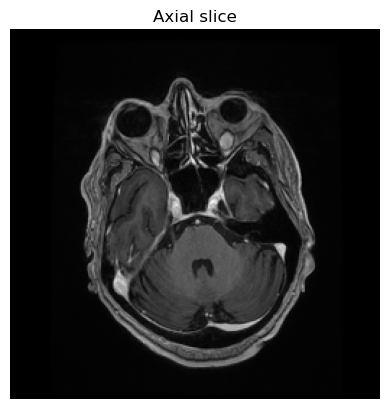

In [3]:
#####         AXIAL         #####
plt.close('all')
plt.figure()
plt.imshow(axial_slice, cmap='gray')
plt.title('Axial slice')
plt.axis('off')
plt.show()

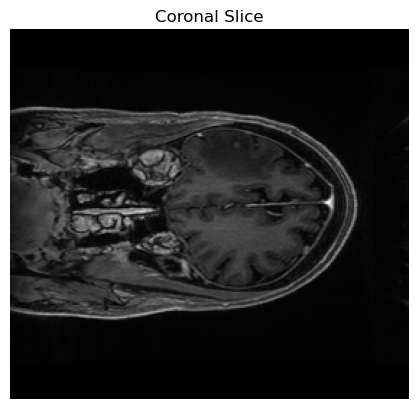

In [4]:
#####    CORONAL    #####
plt.figure()
plt.imshow(coronal_slice.T, cmap='gray') # print pixel data of dicom file
plt.title('Coronal Slice')
plt.axis('off')
plt.show()

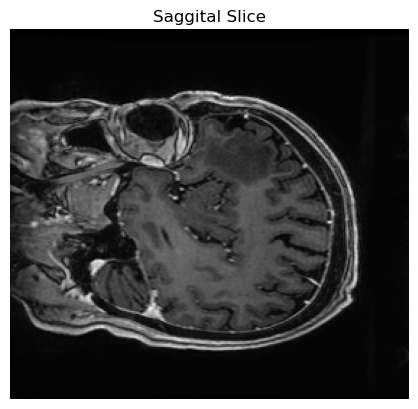

In [5]:
#####    SAGITTAL    #####
plt.figure()
plt.imshow(saggital_slice.T, cmap='gray') # print pixel data of dicom file
plt.title('Saggital Slice')
plt.axis('off')
plt.show()

### With Feedback - Using the data in all the files to generate the coronal and sagittal slices

In [6]:
def list_of_pixel_data(directory):
    all_pixel_data = []
    for index in range(len(os.listdir(directory))):
        if 'MR' in str(os.listdir(directory)[index]):
            entry = os.listdir(directory)[index]
            ds = pydicom.dcmread(os.path.join(directory, entry))
            pixel_data = ds.pixel_array
            all_pixel_data.append(pixel_data)
    return all_pixel_data

Pat1_directory = r'C:\Users\slaar\Desktop\project\HippocampalMRISlices\01' #Pat1 meaning patient 1
Pat1_pixel_data = np.array(list_of_pixel_data(Pat1_directory))


In [7]:
Pat1_pixel_data.shape

(276, 256, 256)

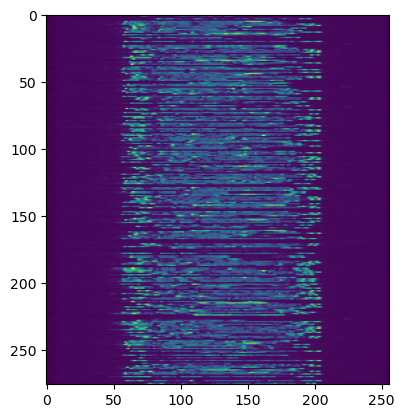

In [8]:
plt.figure()
plt.imshow(Pat1_pixel_data[:,:,70])

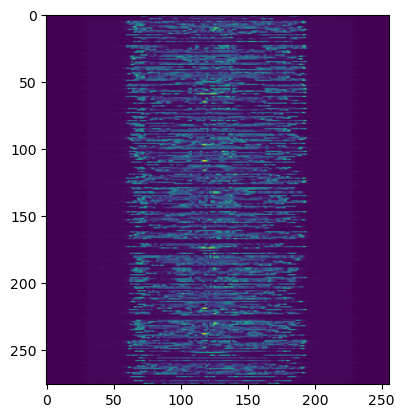

In [9]:
plt.figure()
plt.imshow(Pat1_pixel_data[:,70,:])

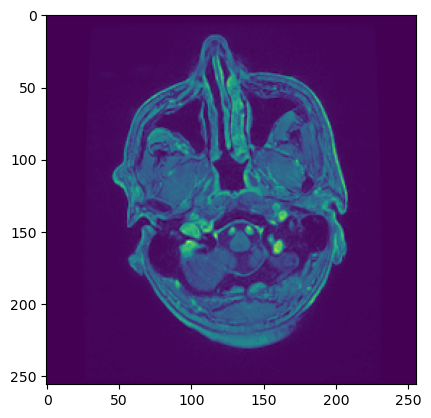

In [ ]:
## axial
plt.figure()
plt.imshow(Pat1_pixel_data[70,:,:])